# Cardiac Strain Analysis — Frame-by-Frame GRS & GCS

Computes Global Radial Strain (GRS) and Global Circumferential Strain (GCS)
from a 4D segmentation NIfTI file across the full cardiac cycle.

## How it works
- Loads all frames from a single 4D NIfTI file
- Computes wall thickness per AHA segment for every frame using ray-casting
- Computes GRS and GCS between every consecutive frame pair
- Shows strain curves, peak strain bullseyes, and per-segment heatmaps

## Strain definitions
- **GRS** = (WT_next − WT_current) / WT_current × 100%  [normal peak > +40%]
- **GCS** = (Circ_next − Circ_current) / Circ_current × 100%  [normal peak −15% to −25%]

## Mask class convention
| Class | Structure |
|-------|-----------|
| 0 | Background |
| 1 | RV |
| 2 | Myocardium |
| 3 | LV cavity |

## How to run
1. Run **Install** cell once
2. Run **Select File** cell — file browser opens
3. Select your 4D segmentation `.nii` or `.nii.gz` file
4. Run all remaining cells

## 1. Install Dependencies

In [ ]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "nibabel", "numpy", "matplotlib", "scipy", "-q"],
    capture_output=True, text=True
)
print("Dependencies ready." if result.returncode == 0 else result.stderr)

## 2. Imports

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy import ndimage
import nibabel as nib
import os

print("Imports OK.")

Imports OK.


## 3. Select Your 4D Segmentation File

Select a single `.nii` or `.nii.gz` file containing all cardiac phases (frames).  
The file should be 4D with shape **H × W × Slices × Frames** (e.g. 9 frames for a typical cine).  
3D files (single frame) are accepted but cannot produce strain — at least 2 frames are required.

In [14]:
import tkinter as tk
from tkinter import filedialog

def pick_nifti_file(title="Select 4D segmentation NIfTI"):
    """Open a native file browser dialog and return the selected path."""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    path = filedialog.askopenfilename(
        title=title,
        filetypes=[("NIfTI files", "*.nii *.nii.gz"), ("All files", "*.*")]
    )
    root.destroy()
    return path if path else None

N_RAYS = 360  # ray-casting resolution: 360 rays = 1° per ray

print("Opening file browser...")
NIFTI_PATH = pick_nifti_file()
if NIFTI_PATH:
    print(f"Selected: {NIFTI_PATH}")
else:
    print("No file selected. Re-run this cell.")

Opening file browser...
Selected: C:/Users/hp193/Downloads/patient005_4d_segmentation (2).nii/patient005_4d_segmentation (2).nii


## 4. Load 4D Segmentation Mask

Loads the NIfTI file and normalises it to 4D shape (H × W × Slices × Frames).  
3D files are wrapped as a single frame. At least 2 frames are required for strain computation.

In [15]:
if not NIFTI_PATH or not os.path.exists(NIFTI_PATH):
    raise FileNotFoundError("No file selected. Re-run the Select File cell.")

nii   = nib.load(NIFTI_PATH)
data  = nii.get_fdata().astype(np.uint8)
zooms = nii.header.get_zooms()

print(f"Raw shape  : {data.shape}")
print(f"Voxel size : {zooms}")
print(f"Classes    : {np.unique(data)}")

# Normalise to 4D (H, W, Slices, Frames)
if data.ndim == 3:
    data = data[:, :, :, np.newaxis]
    print("3D file — treated as 1 frame.")
elif data.ndim == 4:
    print(f"4D file — {data.shape[3]} frames.")
else:
    raise ValueError(f"Unexpected shape: {data.shape}")

n_frames = data.shape[3]
n_slices = data.shape[2]
vox_xy   = float(zooms[0])

if n_frames < 2:
    raise ValueError(
        "Only 1 frame found — cannot compute strain.\n"
        "Strain requires at least 2 frames (consecutive cardiac phases)."
    )

print(f"\nFrames : {n_frames}")
print(f"Slices : {n_slices}")
print(f"Voxel  : {vox_xy:.4f} mm/px")
print()
for f in range(n_frames):
    lv  = np.sum(data[:, :, :, f] == 3)
    myo = np.sum(data[:, :, :, f] == 2)
    print(f"  Frame {f:2d}: LV={lv:5d} px, Myo={myo:5d} px")

Raw shape  : (256, 216, 10, 30)
Voxel size : (np.float32(1.40625), np.float32(1.40625), np.float32(10.0), np.float32(1.0))
Classes    : [0 1 2 3]
4D file — 30 frames.

Frames : 30
Slices : 10
Voxel  : 1.4062 mm/px

  Frame  0: LV=14783 px, Myo=10177 px
  Frame  1: LV=14823 px, Myo=10364 px
  Frame  2: LV=14837 px, Myo=10658 px
  Frame  3: LV=15252 px, Myo=10815 px
  Frame  4: LV=15518 px, Myo=11138 px
  Frame  5: LV=15356 px, Myo=11296 px
  Frame  6: LV=14625 px, Myo=11452 px
  Frame  7: LV=13799 px, Myo=11291 px
  Frame  8: LV=12754 px, Myo=11481 px
  Frame  9: LV=12004 px, Myo=11399 px
  Frame 10: LV=11703 px, Myo=11390 px
  Frame 11: LV=11671 px, Myo=11430 px
  Frame 12: LV=11635 px, Myo=11469 px
  Frame 13: LV=11427 px, Myo=11541 px
  Frame 14: LV=11570 px, Myo=11517 px
  Frame 15: LV=11845 px, Myo=11411 px
  Frame 16: LV=11847 px, Myo=11428 px
  Frame 17: LV=12050 px, Myo=11281 px
  Frame 18: LV=12211 px, Myo=11263 px
  Frame 19: LV=12509 px, Myo=11077 px
  Frame 20: LV=12717 px, 

## 5. Wall Thickness Computation (All Frames)

For each frame and each valid slice:
1. Find LV centroid from class 3 pixels using `scipy.ndimage.center_of_mass`
2. Cast 360 rays radially outward from the centroid
3. Per ray: find **inner radius** (first non-LV pixel = LV→myocardium boundary) and **outer radius** (last myocardium pixel)
4. Wall thickness per ray = outer − inner radius
5. Average across valid rays → per-slice mean wall thickness
6. Rays are grouped into AHA sectors and mapped to 17 segments

Slices with < 10 LV pixels, < 10 myocardium pixels, or < 36 valid rays are skipped.

In [16]:
# ── Ray-casting helpers ───────────────────────────────────────────────────────

def compute_centroid(sl):
    """LV centroid from class 3 pixels. Returns (row, col) or None."""
    lv = (sl == 3).astype(float)
    if lv.sum() < 10:
        return None
    M = ndimage.center_of_mass(lv)
    return M[0], M[1]


def ray_cast(sl, cx, cy, angle_deg, max_r=300):
    """
    Cast one ray. Returns (inner_radius, outer_radius) in pixels or (None, None).
    inner = first pixel NOT LV cavity (LV->myo boundary)
    outer = last pixel that IS myocardium
    """
    H, W = sl.shape
    dx   = np.cos(np.deg2rad(angle_deg))
    dy   = np.sin(np.deg2rad(angle_deg))
    inner_r = outer_r = None
    for r in range(1, max_r):
        x, y   = cx + r * dx, cy + r * dy
        xi, yi = int(round(x)), int(round(y))
        if xi < 0 or xi >= W or yi < 0 or yi >= H:
            break
        pix = sl[yi, xi]
        if inner_r is None and pix != 3:
            inner_r = r
        if inner_r is not None and pix == 2:
            outer_r = r
        if inner_r is not None and outer_r is not None and pix not in [2, 3]:
            break
    return inner_r, outer_r


def compute_frame_metrics(frame_mask, n_rays=N_RAYS):
    """
    For one 3D frame mask, compute per-slice metrics.

    Returns
    -------
    slice_wt     : list of mean wall thickness (px) per valid slice
    slice_ir     : list of mean inner radius (px) per valid slice
    slice_rays   : list of per-ray thickness lists per valid slice
    valid_slices : list of valid slice indices
    """
    slice_wt, slice_ir, slice_rays, valid_slices = [], [], [], []
    for s in range(frame_mask.shape[2]):
        sl = frame_mask[:, :, s]
        if np.sum(sl == 3) < 10 or np.sum(sl == 2) < 10:
            continue
        c = compute_centroid(sl)
        if c is None:
            continue
        cy, cx = c
        rays, inners = [], []
        for a in range(n_rays):
            ir, or_ = ray_cast(sl, cx, cy, a)
            if ir and or_ and or_ > ir:
                rays.append(or_ - ir)
                inners.append(ir)
            else:
                rays.append(None)
                inners.append(None)
        valid_r = [t for t in rays   if t is not None]
        valid_i = [t for t in inners if t is not None]
        if len(valid_r) < 36:
            continue
        slice_wt.append(np.mean(valid_r))
        slice_ir.append(np.mean(valid_i))
        slice_rays.append(rays)
        valid_slices.append(s)
    return slice_wt, slice_ir, slice_rays, valid_slices


def classify_slices(n_valid):
    """Classify n_valid slices into basal/mid/apical/apex."""
    n_apex      = 1
    n_remaining = max(n_valid - n_apex, 3)
    n_basal     = max(1, round(n_remaining / 3))
    n_mid       = max(1, round(n_remaining / 3))
    n_apical    = max(1, n_remaining - n_basal - n_mid)
    while n_basal + n_mid + n_apical > n_remaining and n_basal > 1:
        n_basal -= 1
    labels = (['basal'] * n_basal + ['mid'] * n_mid +
               ['apical'] * n_apical + ['apex'] * n_apex)
    return labels[:n_valid]


def metrics_to_17_segments(slice_wt, slice_ir, slice_labels):
    """
    Map per-slice wall thickness and inner radius to 17 AHA segments.

    Returns (wt_17, circ_17) both in pixels.
    circ = 2*pi*mean_inner_radius per ring, spread across segments in that ring.
    """
    ring_defs = [('basal', 6), ('mid', 6), ('apical', 4), ('apex', 1)]
    wt_17   = []
    circ_17 = []
    for ring, n_sec in ring_defs:
        idxs = [i for i, l in enumerate(slice_labels) if l == ring]
        # Wall thickness: mean across all slices in ring, replicated per sector
        wt_vals = [slice_wt[i] for i in idxs]
        wt_mean = np.mean(wt_vals) if wt_vals else np.nan
        wt_17.extend([wt_mean] * n_sec)
        # Inner radius: mean per ring -> circumference
        ir_vals  = [slice_ir[i] for i in idxs]
        mean_ir  = np.mean(ir_vals) if ir_vals else np.nan
        circ_val = 2 * np.pi * mean_ir if not np.isnan(mean_ir) else np.nan
        circ_17.extend([circ_val] * n_sec)
    return wt_17, circ_17


# ── Compute for all frames ─────────────────────────────────────────────────────
print("Computing wall thickness and inner radius for all frames...\n")

all_frame_wt   = []
all_frame_circ = []

for f in range(n_frames):
    frame_mask = data[:, :, :, f]
    s_wt, s_ir, s_rays, v_slices = compute_frame_metrics(frame_mask)

    if len(v_slices) == 0:
        print(f"  Frame {f:2d}: no valid slices — NaN")
        all_frame_wt.append([np.nan] * 17)
        all_frame_circ.append([np.nan] * 17)
        continue

    labels = classify_slices(len(v_slices))
    wt_17, circ_17 = metrics_to_17_segments(s_wt, s_ir, labels)
    all_frame_wt.append(wt_17)
    all_frame_circ.append(circ_17)

    mean_wt_mm = np.nanmean([w for w in wt_17   if not np.isnan(w)]) * vox_xy
    mean_ir_mm = np.nanmean([c / (2 * np.pi) for c in circ_17 if not np.isnan(c)]) * vox_xy
    print(f"  Frame {f:2d}: {len(v_slices)} slices, "
          f"mean WT={mean_wt_mm:.2f} mm, mean inner_r={mean_ir_mm:.2f} mm")

all_frame_wt   = np.array(all_frame_wt,   dtype=float)   # (n_frames, 17)
all_frame_circ = np.array(all_frame_circ, dtype=float)   # (n_frames, 17)

# Auto-detect ED (largest LV) and ES (smallest LV)
lv_vols  = [np.sum(data[:, :, :, f] == 3) for f in range(n_frames)]
ed_frame = int(np.argmax(lv_vols))
es_frame = int(np.argmin(lv_vols))
print(f"\nED frame (largest LV) : {ed_frame}  (LV={lv_vols[ed_frame]} px)")
print(f"ES frame (smallest LV): {es_frame}  (LV={lv_vols[es_frame]} px)")
print(f"Shape: wt={all_frame_wt.shape}, circ={all_frame_circ.shape}")

Computing wall thickness and inner radius for all frames...

  Frame  0: 10 slices, mean WT=7.99 mm, mean inner_r=31.66 mm
  Frame  1: 10 slices, mean WT=8.16 mm, mean inner_r=31.66 mm
  Frame  2: 10 slices, mean WT=8.43 mm, mean inner_r=31.64 mm
  Frame  3: 10 slices, mean WT=8.41 mm, mean inner_r=32.14 mm
  Frame  4: 10 slices, mean WT=8.55 mm, mean inner_r=32.43 mm
  Frame  5: 10 slices, mean WT=8.69 mm, mean inner_r=32.27 mm
  Frame  6: 10 slices, mean WT=9.01 mm, mean inner_r=31.47 mm
  Frame  7: 10 slices, mean WT=9.10 mm, mean inner_r=30.61 mm
  Frame  8: 10 slices, mean WT=9.57 mm, mean inner_r=29.42 mm
  Frame  9: 10 slices, mean WT=9.74 mm, mean inner_r=28.55 mm
  Frame 10: 10 slices, mean WT=9.83 mm, mean inner_r=28.22 mm
  Frame 11: 10 slices, mean WT=9.88 mm, mean inner_r=28.19 mm
  Frame 12: 10 slices, mean WT=9.92 mm, mean inner_r=28.14 mm
  Frame 13: 10 slices, mean WT=10.08 mm, mean inner_r=27.84 mm
  Frame 14: 10 slices, mean WT=10.00 mm, mean inner_r=28.06 mm
  Frame

## 6. Compute Frame-by-Frame Strain

For each consecutive frame pair (f → f+1) and each AHA segment:
- **GRS** = (WT[f+1] − WT[f]) / WT[f] × 100%
- **GCS** = (Circ[f+1] − Circ[f]) / Circ[f] × 100%

Global strain per transition = mean across all 17 segments.  
**Peak GRS** = transition with highest global GRS.  
**Peak GCS** = transition with most negative global GCS.

In [17]:
AHA_NAMES = [
    'Basal Anterior',    'Basal Anterolateral', 'Basal Inferolateral',
    'Basal Inferior',    'Basal Inferoseptal',   'Basal Anteroseptal',
    'Mid Anterior',      'Mid Anterolateral',    'Mid Inferolateral',
    'Mid Inferior',      'Mid Inferoseptal',     'Mid Anteroseptal',
    'Apical Anterior',   'Apical Lateral',       'Apical Inferior',
    'Apical Septal',     'Apex'
]

# Reference = ED frame (largest LV volume = relaxed/diastolic state)
wt_ed   = all_frame_wt[ed_frame]    # (17,)
circ_ed = all_frame_circ[ed_frame]  # (17,)

# GRS[f, seg] = (WT[f,seg] - WT[ED,seg]) / WT[ED,seg] * 100
# GCS[f, seg] = (Circ[f,seg] - Circ[ED,seg]) / Circ[ED,seg] * 100
grs_all = np.full((n_frames, 17), np.nan)
gcs_all = np.full((n_frames, 17), np.nan)

for f in range(n_frames):
    for seg in range(17):
        if (not np.isnan(wt_ed[seg]) and not np.isnan(all_frame_wt[f, seg])
                and wt_ed[seg] > 0):
            grs_all[f, seg] = (all_frame_wt[f, seg] - wt_ed[seg]) / wt_ed[seg] * 100
        if (not np.isnan(circ_ed[seg]) and not np.isnan(all_frame_circ[f, seg])
                and circ_ed[seg] > 0):
            gcs_all[f, seg] = (all_frame_circ[f, seg] - circ_ed[seg]) / circ_ed[seg] * 100

# Global strain per frame = mean across all 17 segments
global_grs = np.nanmean(grs_all, axis=1)   # (n_frames,)
global_gcs = np.nanmean(gcs_all, axis=1)   # (n_frames,)

# Peak GRS = frame with highest wall thickening (most positive)
# Peak GCS = frame with most negative circumferential shortening
peak_grs_f = int(np.nanargmax(global_grs))
peak_gcs_f = int(np.nanargmin(global_gcs))

print(f"ED frame (reference, strain=0): {ed_frame}")
print(f"ES frame (expected peak strain): {es_frame}")
print()
print("Per-frame Global Strain (relative to ED):")
print(f"{'Frame':>6}  {'GRS (%)':>9}  {'GCS (%)':>9}")
print("-" * 32)
for f in range(n_frames):
    g  = f"{global_grs[f]:+.2f}" if not np.isnan(global_grs[f]) else "  N/A"
    c  = f"{global_gcs[f]:+.2f}" if not np.isnan(global_gcs[f]) else "  N/A"
    pk = ""
    if f == ed_frame:                    pk += " <- ED (ref)"
    if f == es_frame:                    pk += " <- ES"
    if f == peak_grs_f and f != ed_frame: pk += " <- peak GRS"
    if f == peak_gcs_f and f != ed_frame: pk += " <- peak GCS"
    print(f"  {f:3d}      {g:>9}  {c:>9}{pk}")

print(f"\nPeak GRS: frame {peak_grs_f} = {global_grs[peak_grs_f]:+.2f}%  (normal > +40%)")
print(f"Peak GCS: frame {peak_gcs_f} = {global_gcs[peak_gcs_f]:+.2f}%  (normal -15% to -25%)")

ED frame (reference, strain=0): 4
ES frame (expected peak strain): 13

Per-frame Global Strain (relative to ED):
 Frame    GRS (%)    GCS (%)
--------------------------------
    0          -6.66      -2.33
    1          -4.49      -2.79
    2          -1.22      -3.44
    3          -1.58      -1.73
    4          +0.00      +0.00 <- ED (ref)
    5          +1.54      +0.04
    6          +5.41      -2.25
    7          +6.57      -5.22
    8         +12.03      -9.28
    9         +13.93     -11.90
   10         +14.93     -12.85
   11         +15.43     -12.56
   12         +15.83     -12.62
   13         +17.75     -13.70 <- ES <- peak GRS <- peak GCS
   14         +16.89     -13.44
   15         +14.57     -12.64
   16         +14.79     -12.30
   17         +12.30     -11.11
   18         +11.43     -10.38
   19          +8.79      -9.21
   20          +7.25      -8.53
   21          +6.24      -7.97
   22          +5.81      -7.90
   23          +6.45      -7.91
   24          

## 7. Strain Curves Across Cardiac Cycle

Shows how global GRS and GCS evolve across all frame transitions.  
The peak strain frame pair is highlighted with a red dot.

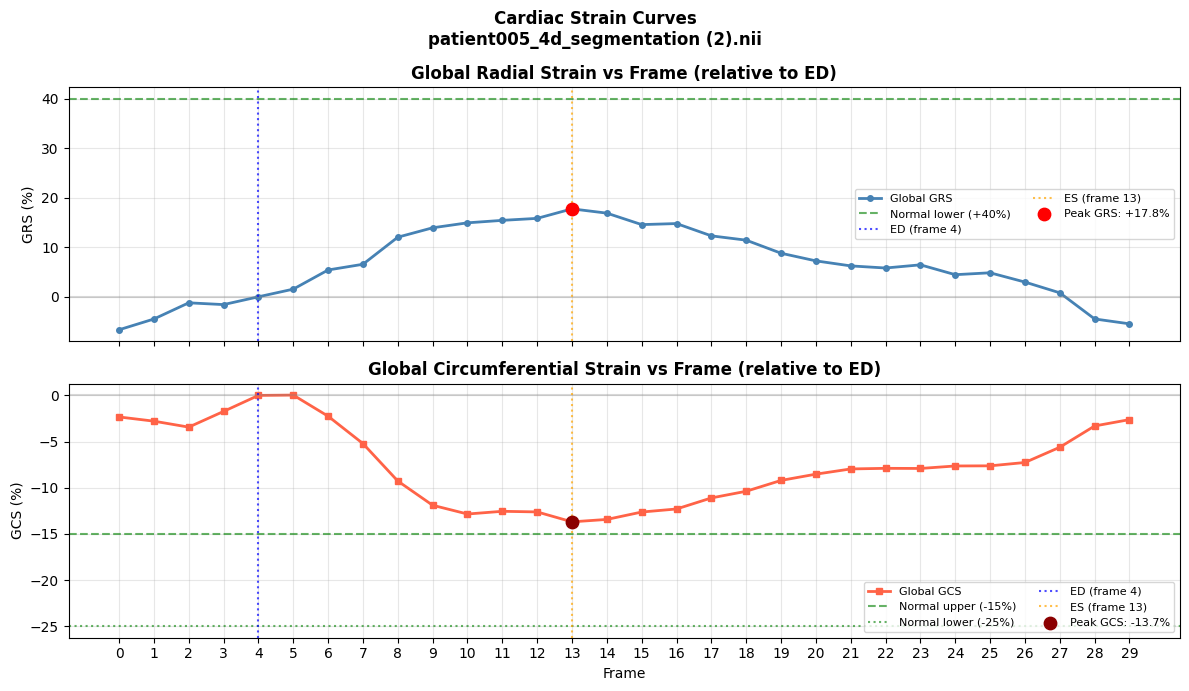

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
x = np.arange(n_frames)

# GRS curve
axes[0].plot(x, global_grs, 'o-', color='steelblue', lw=2, ms=4, label='Global GRS')
axes[0].axhline(y=40, color='green', ls='--', alpha=0.6, label='Normal lower (+40%)')
axes[0].axhline(y=0,  color='gray',  ls='-',  alpha=0.3)
axes[0].axvline(x=ed_frame, color='blue',   ls=':', alpha=0.7, label=f'ED (frame {ed_frame})')
axes[0].axvline(x=es_frame, color='orange', ls=':', alpha=0.7, label=f'ES (frame {es_frame})')
axes[0].scatter([peak_grs_f], [global_grs[peak_grs_f]], color='red', zorder=5, s=80,
                label=f'Peak GRS: {global_grs[peak_grs_f]:+.1f}%')
axes[0].set_ylabel('GRS (%)')
axes[0].set_title('Global Radial Strain vs Frame (relative to ED)', fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

# GCS curve
axes[1].plot(x, global_gcs, 's-', color='tomato', lw=2, ms=4, label='Global GCS')
axes[1].axhline(y=-15, color='green', ls='--', alpha=0.6, label='Normal upper (-15%)')
axes[1].axhline(y=-25, color='green', ls=':',  alpha=0.6, label='Normal lower (-25%)')
axes[1].axhline(y=0,   color='gray',  ls='-',  alpha=0.3)
axes[1].axvline(x=ed_frame, color='blue',   ls=':', alpha=0.7, label=f'ED (frame {ed_frame})')
axes[1].axvline(x=es_frame, color='orange', ls=':', alpha=0.7, label=f'ES (frame {es_frame})')
axes[1].scatter([peak_gcs_f], [global_gcs[peak_gcs_f]], color='darkred', zorder=5, s=80,
                label=f'Peak GCS: {global_gcs[peak_gcs_f]:+.1f}%')
axes[1].set_ylabel('GCS (%)')
axes[1].set_xlabel('Frame')
axes[1].set_title('Global Circumferential Strain vs Frame (relative to ED)', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(x)

fig.suptitle(f'Cardiac Strain Curves\n{os.path.basename(NIFTI_PATH)}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. AHA 17-Segment Bullseye at Peak Strain

Shows the per-segment strain distribution at the peak transition for GRS and GCS separately.

**Orientation:** Anterior top (90°), Lateral left (180°), Inferior bottom (270°), Septal right (0°).  
**Rings:** Basal (outer, segments 1–6), Mid (segments 7–12), Apical (segments 13–16), Apex (centre, segment 17).

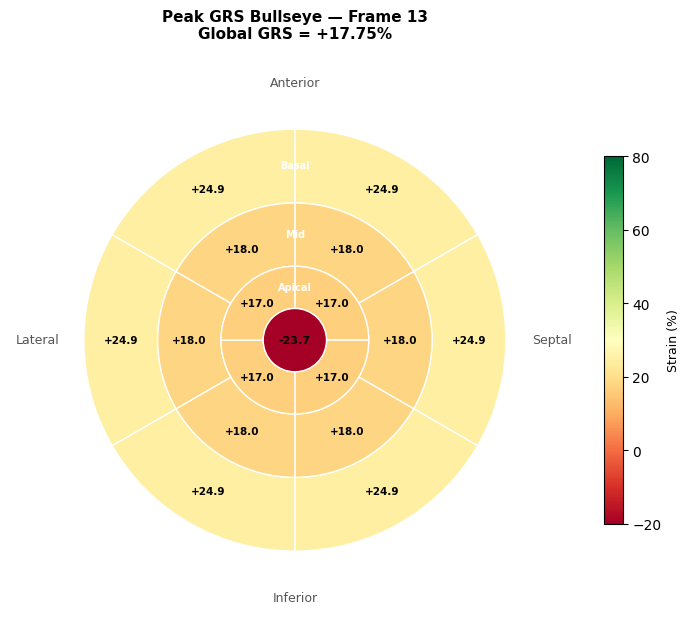

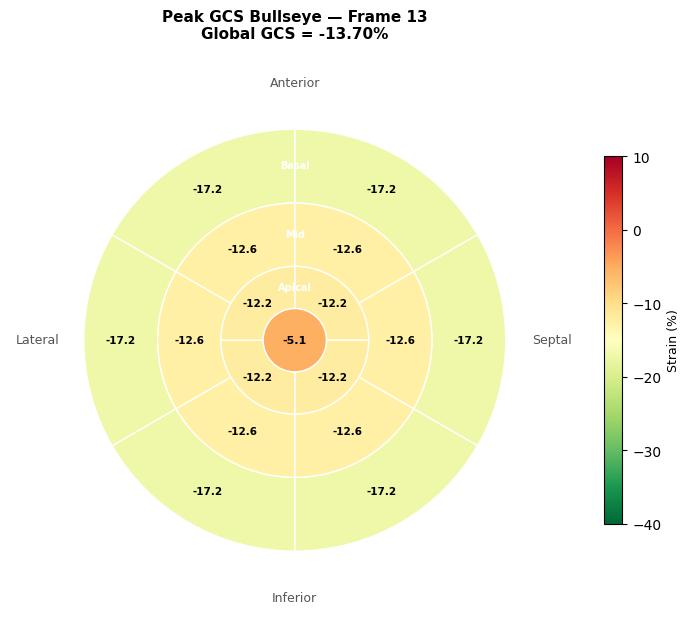

In [19]:
def draw_strain_bullseye(seg_values, title, cmap_name, vmin, vmax, unit='%'):
    """
    Draw AHA 17-segment bullseye coloured by strain value.

    Orientation: Anterior top (90 deg), Lateral left (180 deg),
                 Inferior bottom (270 deg), Septal right (0 deg).
    Segments 1-6 basal (outer), 7-12 mid, 13-16 apical, 17 apex (centre).
    """
    cmap = plt.cm.get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

    rings = [
        (seg_values[0:6],   0.65, 1.0,  6, 90),   # Basal
        (seg_values[6:12],  0.35, 0.65, 6, 90),   # Mid
        (seg_values[12:16], 0.15, 0.35, 4, 90),   # Apical
    ]
    for segs, r_in, r_out, n_sec, start in rings:
        sec_ang = 360 / n_sec
        for i, v in enumerate(segs):
            t1 = start - (i + 1) * sec_ang
            t2 = start - i * sec_ang
            color = cmap(norm(v)) if not np.isnan(v) else '#888888'
            ax.add_patch(Wedge((0, 0), r_out, t1, t2,
                               width=r_out - r_in, color=color, ec='white', lw=1.0))
            mid_ang = np.deg2rad((t1 + t2) / 2)
            mid_r   = (r_in + r_out) / 2
            lbl = f'{v:+.1f}' if not np.isnan(v) else 'N/A'
            ax.text(mid_r * np.cos(mid_ang), mid_r * np.sin(mid_ang), lbl,
                    ha='center', va='center', fontsize=7.5,
                    color='black', fontweight='bold')

    # Apex centre circle
    v17 = seg_values[16]
    c17 = cmap(norm(v17)) if not np.isnan(v17) else '#888888'
    ax.add_patch(plt.Circle((0, 0), 0.15, color=c17, ec='white', lw=1.0))
    ax.text(0, 0, f'{v17:+.1f}' if not np.isnan(v17) else 'N/A',
            ha='center', va='center', fontsize=8,
            color='black', fontweight='bold')

    # Anatomical labels
    for lbl, pos in [('Anterior', (0, 1.22)), ('Inferior', (0, -1.22)),
                      ('Lateral', (-1.22, 0)), ('Septal', (1.22, 0))]:
        ax.text(pos[0], pos[1], lbl, ha='center', va='center',
                fontsize=9, color='#555555')

    # Ring labels
    for lbl, y in [('Basal', 0.83), ('Mid', 0.50), ('Apical', 0.25)]:
        ax.text(0, y, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

    # Colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label(f'Strain ({unit})', fontsize=9)
    plt.tight_layout()
    plt.show()


# Peak GRS bullseye
draw_strain_bullseye(
    grs_all[peak_grs_f],
    title=(f'Peak GRS Bullseye — Frame {peak_grs_f}\n'
           f'Global GRS = {global_grs[peak_grs_f]:+.2f}%'),
    cmap_name='RdYlGn',
    vmin=-20, vmax=80
)

# Peak GCS bullseye
draw_strain_bullseye(
    gcs_all[peak_gcs_f],
    title=(f'Peak GCS Bullseye — Frame {peak_gcs_f}\n'
           f'Global GCS = {global_gcs[peak_gcs_f]:+.2f}%'),
    cmap_name='RdYlGn_r',
    vmin=-40, vmax=10
)

## 9. Per-Segment Strain Heatmaps

Shows how each of the 17 AHA segments changes strain across all frame transitions.  
Rows = AHA segments, Columns = frame transitions.  
Useful for identifying regionally heterogeneous strain patterns.

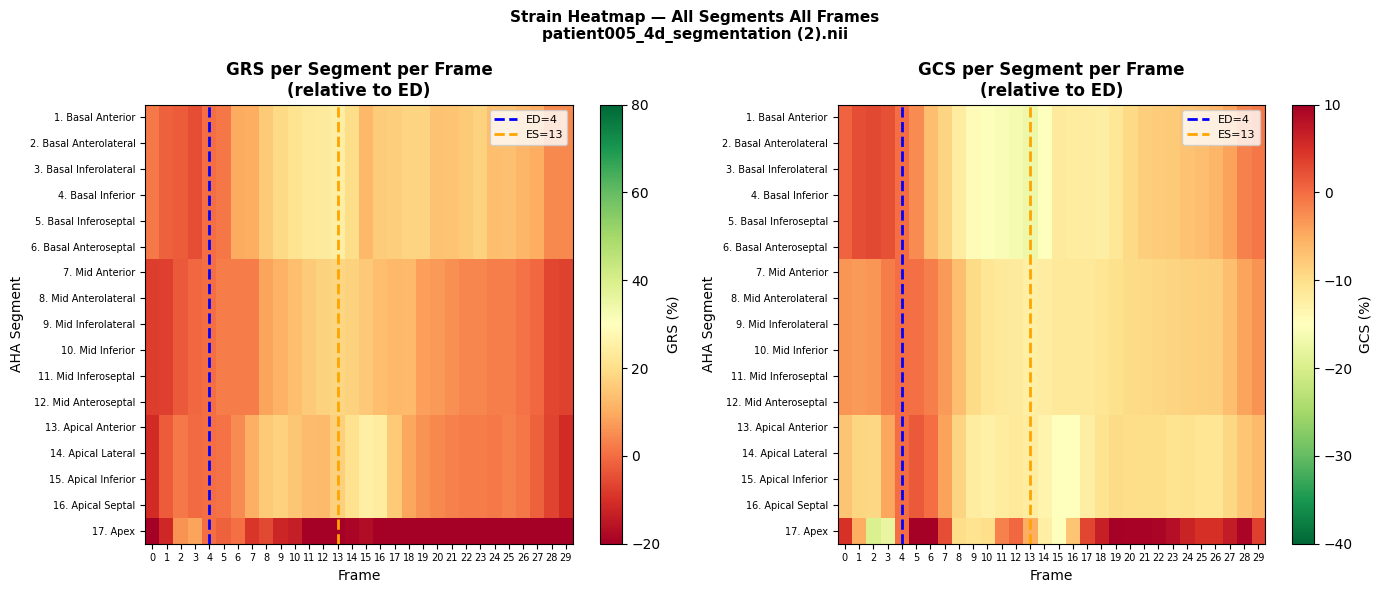

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(grs_all.T, aspect='auto', cmap='RdYlGn', vmin=-20, vmax=80)
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('AHA Segment')
axes[0].set_title('GRS per Segment per Frame\n(relative to ED)', fontweight='bold')
axes[0].set_xticks(range(n_frames))
axes[0].set_xticklabels([str(f) for f in range(n_frames)], fontsize=7)
axes[0].axvline(x=ed_frame, color='blue',   lw=2, ls='--', label=f'ED={ed_frame}')
axes[0].axvline(x=es_frame, color='orange', lw=2, ls='--', label=f'ES={es_frame}')
axes[0].set_yticks(range(17))
axes[0].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=7)
axes[0].legend(fontsize=8)
plt.colorbar(im1, ax=axes[0], label='GRS (%)')

im2 = axes[1].imshow(gcs_all.T, aspect='auto', cmap='RdYlGn_r', vmin=-40, vmax=10)
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('AHA Segment')
axes[1].set_title('GCS per Segment per Frame\n(relative to ED)', fontweight='bold')
axes[1].set_xticks(range(n_frames))
axes[1].set_xticklabels([str(f) for f in range(n_frames)], fontsize=7)
axes[1].axvline(x=ed_frame, color='blue',   lw=2, ls='--', label=f'ED={ed_frame}')
axes[1].axvline(x=es_frame, color='orange', lw=2, ls='--', label=f'ES={es_frame}')
axes[1].set_yticks(range(17))
axes[1].set_yticklabels([f'{i+1}. {n}' for i, n in enumerate(AHA_NAMES)], fontsize=7)
axes[1].legend(fontsize=8)
plt.colorbar(im2, ax=axes[1], label='GCS (%)')

fig.suptitle(f'Strain Heatmap — All Segments All Frames\n{os.path.basename(NIFTI_PATH)}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary Report

In [21]:
print('=' * 60)
print('         CARDIAC STRAIN ANALYSIS — SUMMARY')
print('=' * 60)
print(f'File    : {os.path.basename(NIFTI_PATH)}')
print(f'Frames  : {n_frames}')
print(f'Slices  : {n_slices}')
print(f'Voxel   : {vox_xy:.4f} mm/px')
print(f'ED frame: {ed_frame} (reference, largest LV)')
print(f'ES frame: {es_frame} (smallest LV)')
print()
print('--- Per-Frame Global Strain (relative to ED) ---')
print(f'{"Frame":>6}  {"GRS (%)":>9}  {"GCS (%)":>9}')
print('-' * 32)
for f in range(n_frames):
    g  = f'{global_grs[f]:+.2f}' if not np.isnan(global_grs[f]) else '   N/A'
    c  = f'{global_gcs[f]:+.2f}' if not np.isnan(global_gcs[f]) else '   N/A'
    pk = ''
    if f == ed_frame:                    pk += ' <- ED (ref=0)'
    if f == es_frame:                    pk += ' <- ES'
    if f == peak_grs_f and f != ed_frame: pk += ' <- peak GRS'
    if f == peak_gcs_f and f != ed_frame: pk += ' <- peak GCS'
    print(f'  {f:3d}      {g:>9}  {c:>9}{pk}')
print()
print('--- Peak Values ---')
print(f'Peak GRS : {global_grs[peak_grs_f]:+.2f}%  (frame {peak_grs_f})')
print(f'  Normal  : > +40%')
grs_i = ('NORMAL'         if global_grs[peak_grs_f] >= 40 else
          'MILDLY REDUCED' if global_grs[peak_grs_f] >= 20 else 'REDUCED')
print(f'  Status  : {grs_i}')
print()
print(f'Peak GCS : {global_gcs[peak_gcs_f]:+.2f}%  (frame {peak_gcs_f})')
print(f'  Normal  : -15% to -25%')
gcs_i = ('NORMAL'       if -25 <= global_gcs[peak_gcs_f] <= -15 else
          'REDUCED'       if global_gcs[peak_gcs_f] > -15         else 'HYPERDYNAMIC')
print(f'  Status  : {gcs_i}')
print('=' * 60)

         CARDIAC STRAIN ANALYSIS — SUMMARY
File    : patient005_4d_segmentation (2).nii
Frames  : 30
Slices  : 10
Voxel   : 1.4062 mm/px
ED frame: 4 (reference, largest LV)
ES frame: 13 (smallest LV)

--- Per-Frame Global Strain (relative to ED) ---
 Frame    GRS (%)    GCS (%)
--------------------------------
    0          -6.66      -2.33
    1          -4.49      -2.79
    2          -1.22      -3.44
    3          -1.58      -1.73
    4          +0.00      +0.00 <- ED (ref=0)
    5          +1.54      +0.04
    6          +5.41      -2.25
    7          +6.57      -5.22
    8         +12.03      -9.28
    9         +13.93     -11.90
   10         +14.93     -12.85
   11         +15.43     -12.56
   12         +15.83     -12.62
   13         +17.75     -13.70 <- ES <- peak GRS <- peak GCS
   14         +16.89     -13.44
   15         +14.57     -12.64
   16         +14.79     -12.30
   17         +12.30     -11.11
   18         +11.43     -10.38
   19          +8.79      -9.21
   2